In [1]:
import sys
sys.path.append("..")
from dotenv import load_dotenv
load_dotenv("../.env")

import matplotlib.pyplot as plt
from src.db import read_sql

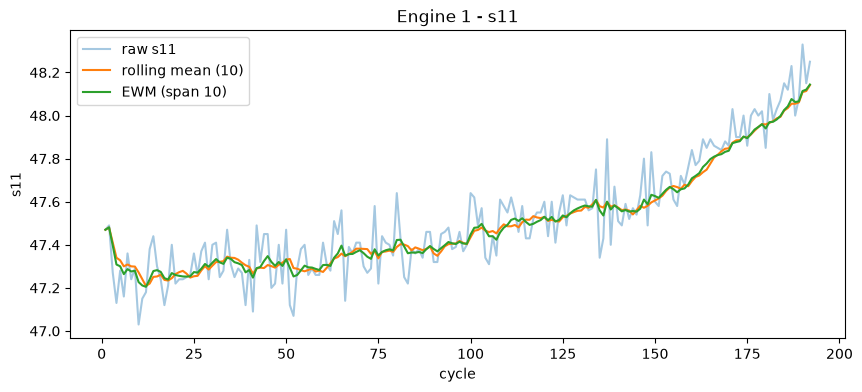

In [2]:
f = read_sql("""
    SELECT cycle, s11, s11_mean10, s11_ewm, rul, rul_true
    FROM feat.fd001_train WHERE unit_id = 1 ORDER BY cycle
""")

plt.figure(figsize=(10, 4))
plt.plot(f["cycle"], f["s11"], alpha=0.4, label="raw s11")
plt.plot(f["cycle"], f["s11_mean10"], label="rolling mean (10)")
plt.plot(f["cycle"], f["s11_ewm"], label="EWM (span 10)")
plt.xlabel("cycle"); plt.ylabel("s11"); plt.legend(); plt.title("Engine 1 - s11")
plt.show()

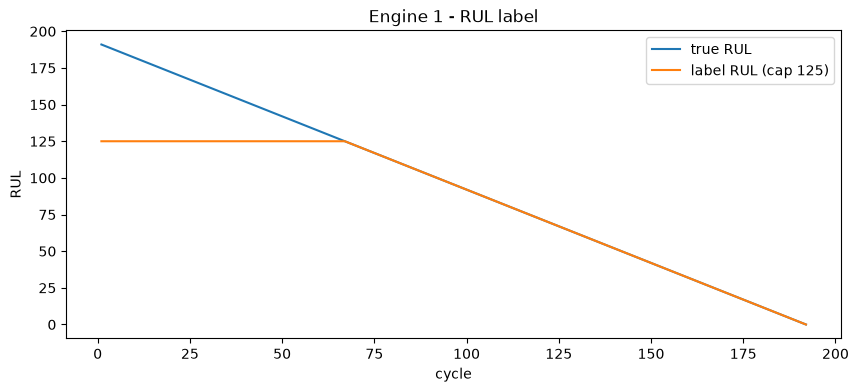

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(f["cycle"], f["rul_true"], label="true RUL")
plt.plot(f["cycle"], f["rul"], label="label RUL (cap 125)")
plt.xlabel("cycle"); plt.ylabel("RUL"); plt.legend(); plt.title("Engine 1 - RUL label")
plt.show()